# Clase 22: Estrategias neutrales de trading con opciones

> **Objetivo:** Construir y analizar las estrategias que apuestan a que el mercado se queda dentro de un rango, butterfly, iron condor, covered call y protective put. Entender la diferencia entre comprar y vender volatilidad, y conectar estas estrategias con la IV y las griegas.
> 

---

Esta clase usa las funciones `payoff_estrategia()` y `graficar_estrategia()` definidas en la Clase 19. Asegúrate de tenerlas disponibles en tu sesión.

---

## 1. ¿Qué es una estrategia neutral?

A diferencia de las estrategias de la clase pasada, las estrategias neutrales ganan cuando el subyacente **no se mueve mucho**, cuando el precio se queda dentro de un rango predefinido. Son posiciones de **venta de volatilidad**: cobras prima hoy a cambio de asumir el riesgo de que el mercado se mueva demasiado.

Cuando la IV es alta, las primas son caras y vender volatilidad es más atractivo. Un trader que ve la superficie de volatilidad con IV elevada en opciones de corto plazo tiene un incentivo natural a construir estrategias neutrales pues cobra más prima por el mismo riesgo.

En términos de griegas, estas estrategias tienen **vega negativa y theta positiva**: pierden si la IV sube, pero ganan dinero todos los días por el simple paso del tiempo.

---

## 2. Butterfly Spread

### ¿Qué es?

Combina un bull spread y un bear spread que comparten el strike central K2. El resultado es una posición con forma triangular: ganancia máxima si el precio termina exactamente en K2, pérdida limitada si termina en los extremos.

### ¿Cuándo usarlo?

El butterfly es una apuesta de **precisión**: crees que el precio terminará cerca de un nivel específico. Es útil cuando tienes una expectativa concreta sobre dónde quedará SPY al vencimiento y quieres apostar a ello con riesgo limitado en ambas direcciones.

A diferencia del iron condor, el butterfly tiene un pico de ganancia estrecho, requiere más precisión en la dirección del precio. El costo es generalmente bajo porque los spreads se compensan.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # Línea de precio actual
    if S0 is not None:
        plt.axvline(S0, color='blue', linestyle='--', linewidth=1, label=f'S0={S0}')

    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Prima neta pagada : $3.76
Ganancia máxima   : $16.24  (si ST =680)
Pérdida máxima    : $-3.76
Break-even inf.   : $663.76  |  sup.: $696.24


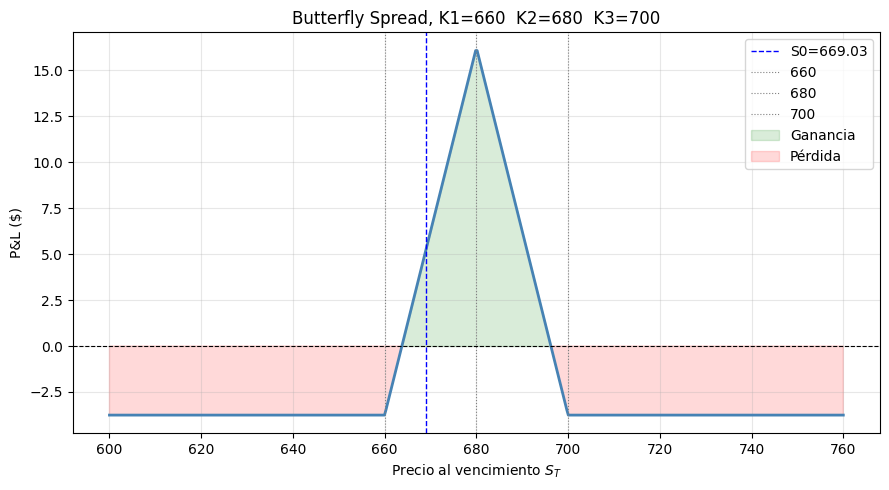

In [3]:
S_range = np.linspace(600, 760, 500)
S0 = 669.03

K1, K2, K3 = 660, 680, 700
C1, C2, C3 = 18.00, 9.37, 4.50

legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_butterfly)
prima_neta = C1 - 2*C2 + C3

print(f"Prima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${(K2-K1)-prima_neta:.2f}  (si ST ={K2})")
print(f"Pérdida máxima    : ${-prima_neta:.2f}")
print(f"Break-even inf.   : ${K1+prima_neta:.2f}  |  sup.: ${K3-prima_neta:.2f}")

graficar_estrategia(S_range, pnl, f'Butterfly Spread, K1={K1}  K2={K2}  K3={K3}',
                    S0=S0, K_lines=[(K1,f'{K1}'),(K2,f'{K2}'),(K3,f'{K3}')])

## 3. Iron Condor

### ¿Qué es?

Combina un put spread vendido y un call spread vendido, creando una zona ancha de ganancia entre los cuatro strikes. Cobras prima neta desde el inicio, ganas si el precio se queda dentro del rango al vencimiento.

### ¿Cuándo usarlo?

El iron condor es la estrategia neutral por excelencia y una de las más usadas por traders profesionales. Tiene sentido cuando:

- Esperas que el mercado se mueva poco en las próximas semanas, mercado lateral con baja incertidumbre.
- La IV está elevada, lo que significa que estás cobrando primas altas. Si la IV luego baja, la posición gana por vega negativa incluso antes del vencimiento.
- Quieres generar ingreso regular con riesgo definido en ambas direcciones.

La zona de ganancia del condor es más ancha que la del butterfly, pero la ganancia máxima es la prima cobrada, no hay pico. El riesgo es que el precio salga del rango, en cuyo caso la pérdida está limitada por el ancho de los spreads.

Prima cobrada     : $9.60  (ganancia máxima)
Pérdida máxima    : $10.40
Zona de ganancia  : [660,700]


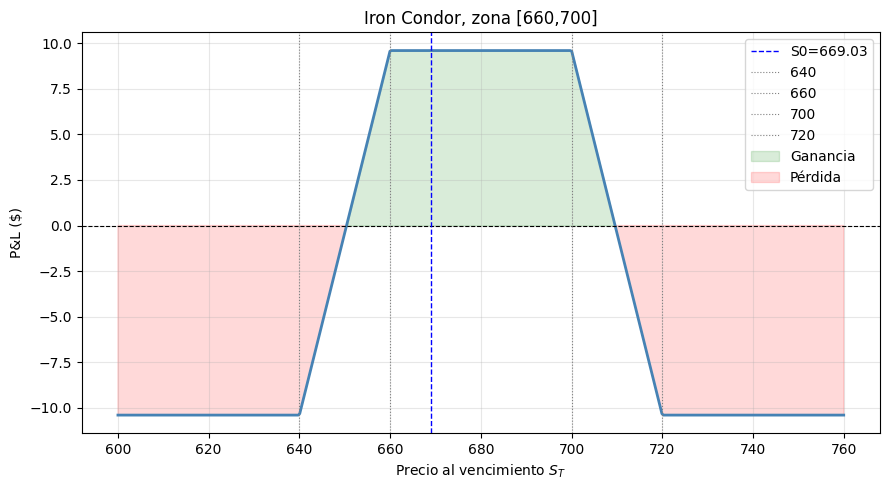

In [4]:
K_pl, K_ps = 640, 660     # put leg: long K_pl, short K_ps
K_cs, K_cl = 700, 720     # call leg: short K_cs, long K_cl
P_l, P_s   = 5.50, 11.20
C_s, C_l   = 6.80, 2.90

legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"Prima cobrada     : ${prima_cobrada:.2f}  (ganancia máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps},{K_cs}]")

graficar_estrategia(S_range, pnl,
                    f'Iron Condor, zona [{K_ps},{K_cs}]', S0=S0,
                    K_lines=[(K_pl,f'{K_pl}'),(K_ps,f'{K_ps}'),
                             (K_cs,f'{K_cs}'),(K_cl,f'{K_cl}')])

## 4. Covered Call

### ¿Qué es?

Tienes acciones del subyacente y vendes un call OTM sobre ellas. Cobras la prima del call a cambio de ceder la ganancia potencial por encima de K. La prima actúa como un ingreso adicional, o como un amortiguador parcial contra caídas.

### ¿Cuándo usarlo?

El covered call es la estrategia más común entre inversores de largo plazo que quieren **generar ingreso** sobre sus posiciones. Tiene sentido cuando:

- Tienes SPY en cartera y crees que no subirá mucho en el corto plazo.
- Quieres reducir el costo efectivo de tu posición cobrando primas regularmente.
- Estás dispuesto a vender tus acciones al precio K si el mercado llega ahí.

La desventaja es que limitas tu upside: si SPY sube mucho más allá de K, pierdes esa ganancia porque estás obligado a vender a K.

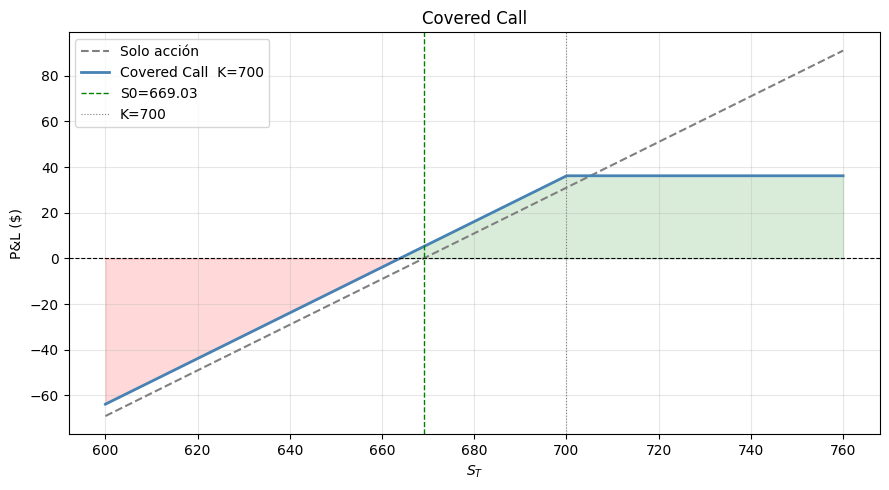

Ganancia máxima : $36.17  (si ST ≥700)
Break-even      : $663.83


In [5]:
K_cc, C_cc = 700, 5.20
pnl_accion  = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,  color='gray',      linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_covered, color='steelblue', linewidth=2,
         label=f'Covered Call  K={K_cc}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0}')
plt.axvline(K_cc, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_cc}')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_covered, 0, where=(pnl_covered<0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Covered Call'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥{K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")

## 5. Protective Put

### ¿Qué es?

Tienes acciones y compras un put OTM para protegerte de una caída. La prima que pagas es el costo del seguro, a cambio tienes un piso: si SPY cae por debajo de K, el put compensa la pérdida de la acción.

### ¿Cuándo usarlo?

El protective put es el **seguro de cartera** más directo. Tiene sentido cuando:

- Tienes una posición larga en SPY que no quieres vender (por razones fiscales, por convicción de largo plazo, etc.), pero temes una corrección de corto plazo.
- La IV está baja, el seguro es barato en ese momento.
- Hay un evento de riesgo conocido próximo y quieres estar cubierto.

La analogía con un seguro de auto es precisa: pagas una prima periódicamente para estar protegido contra un evento que esperas que no ocurra, pero cuyas consecuencias serían graves si ocurriera.

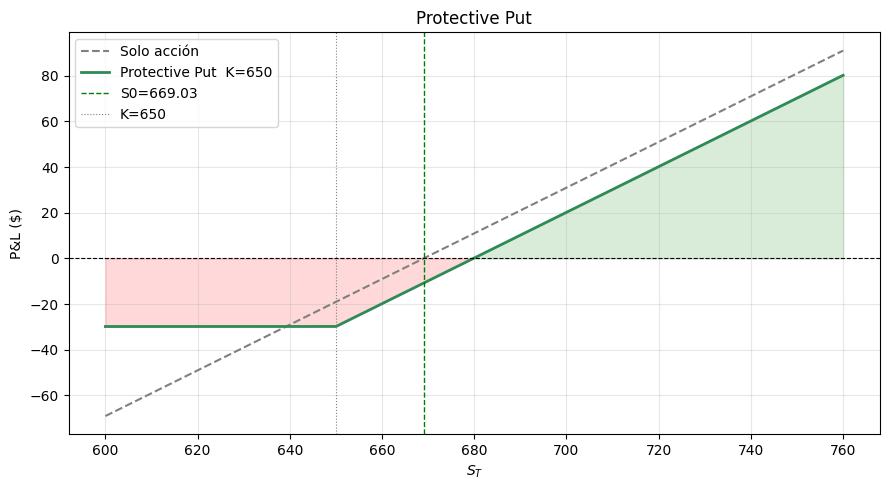

Pérdida máxima : $-29.83  (si ST ≤650)
Break-even     : $679.83


In [7]:
K_pp, P_pp = 650, 10.80
pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)

plt.figure(figsize=(9, 5))
plt.plot(S_range, pnl_accion,     color='gray',    linewidth=1.5,
         linestyle='--', label='Solo acción')
plt.plot(S_range, pnl_protective, color='seagreen', linewidth=2,
         label=f'Protective Put  K={K_pp}')
plt.axhline(0,    color='black', linewidth=0.8, linestyle='--')
plt.axvline(S0,   color='green', linewidth=1.0, linestyle='--', label=f'S0={S0}')
plt.axvline(K_pp, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K_pp}')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective>0), alpha=0.15, color='green')
plt.fill_between(S_range, pnl_protective, 0, where=(pnl_protective<0), alpha=0.15, color='red')
plt.xlabel('$S_T$'); plt.ylabel('P&L ($)')
plt.title('Protective Put'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤{K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")

## 6. Tabla resumen
| Estrategia | Vista del mercado | Ganancia máx. | Pérdida máx. | Vega |
| --- | --- | --- | --- | --- |
| Butterfly | Se queda en K2 | K2 - K1 - prima | Prima neta | Negativa |
| Iron Condor | Se queda en rango | Prima cobrada | Ancho spread - prima | Negativa |
| Covered Call | Lateral o sube poco | K - S0 + prima | S0 - prima (downside) | Negativa |
| Protective Put | Protección downside | Ilimitada (upside) | S0 - K + prima | Positiva |

# Rep. 4. Checkpoint 3. Estrategias II

Esta actividad es necesaria para el reporte integrador 4.

Esta actividad complementa el contenido de la clase "Estrategias neutrales de trading con opciones".

Usando el código visto en clase y datos reales de SPY con vencimiento al 17 de abril de 2026, replicarás los payoff diagrams de las cuatro estrategias neutrales (butterfly, iron condor, covered call y protective put) y analizarás bajo qué condiciones de mercado y de volatilidad implícita tiene sentido cada una.

## Contexto

Las estrategias neutrales son la otra cara de la moneda del trading con opciones: en lugar de apostar a un movimiento, apuestas a la quietud. Vendes volatilidad, cobras prima y dejas que el tiempo trabaje a tu favor. Pero esa prima no es gratis: es la compensación por asumir el riesgo de que el mercado se mueva más de lo que esperas. Entender cuándo vender volatilidad (IV alta, mercado lateral, theta positiva) y cuándo no, es una de las decisiones más importantes que toma un trader de opciones.

## Instrucciones

Toma el código desarrollado en clase para las cuatro estrategias neutrales (butterfly, iron condor, covered call y protective put) y ejecútalo en tu notebook usando los precios mid reales de SPY con vencimiento 2026-04-17, obtenidos dinámicamente con yfinance (siguiendo el mismo patrón visto en clase). No necesitas escribir código nuevo: la actividad consiste en correr el código de clase con datos actualizados y presentar:

- El payoff diagram del butterfly spread

- El payoff diagram del iron condor

- El payoff diagram del covered call

- El payoff diagram del protective put

- Una tabla resumen con prima neta (pagada o cobrada), ganancia máxima, pérdida máxima y break-even(s) de cada estrategia (los valores ya se imprimen en el código de clase, basta con consolidarlos en una tabla).

In [8]:
import yfinance as yf 

# Obtener datos de GLD (Oro)
gld = yf.Ticker("GLD")
S0 = gld.history(period="1d")['Close'].iloc[-1]

# Obtener cadena de opciones para el vencimiento
vencimiento = '2026-04-17'
opciones = gld.option_chain(vencimiento)
calls = opciones.calls
puts = opciones.puts

# Función auxiliar para obtener el precio mid
def get_mid_price(df, strike):
    row = df[df['strike'] == strike]
    if not row.empty:
        return (row['bid'].values[0] + row['ask'].values[0]) / 2
    return 0

# Rango de precios para la simulación
S_range = np.linspace(S0 * 0.8, S0 * 1.2, 500)

# Seleccionar strikes cercanos al precio actual (ATM)
strike_atm = round(S0 / 5) * 5 # Redondea al strike múltiplo de 5 más cercano
ancho = 10 # Ancho del spread

K1 = strike_atm - ancho
K2 = strike_atm
K3 = strike_atm + ancho

--- BUTTERFLY SPREAD ---
Prima neta pagada : $3.54
Ganancia máxima   : $6.46
Pérdida máxima    : $-3.54


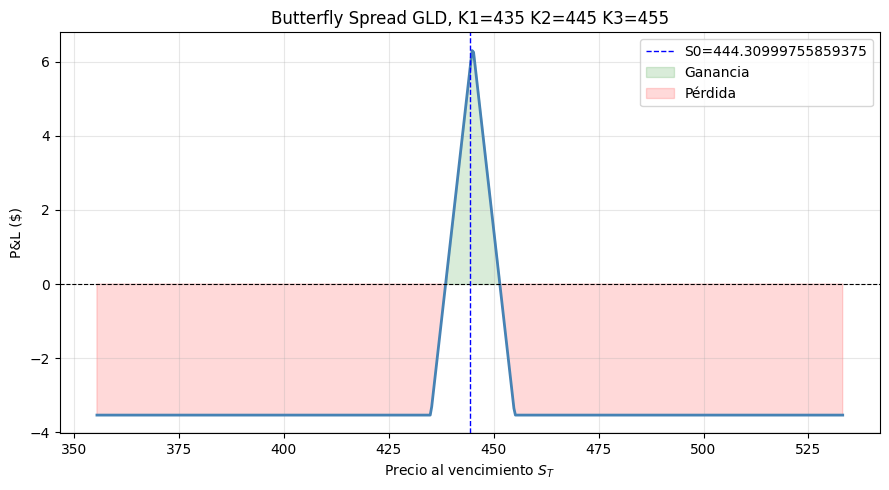

In [9]:
# 1. Butterfly Spread 
C1 = get_mid_price(calls, K1)
C2 = get_mid_price(calls, K2)
C3 = get_mid_price(calls, K3)

legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]
pnl_butterfly = payoff_estrategia(S_range, legs_butterfly)
prima_neta_bf = C1 - 2*C2 + C3

print("--- BUTTERFLY SPREAD ---")
print(f"Prima neta pagada : ${prima_neta_bf:.2f}")
print(f"Ganancia máxima   : ${(K2-K1)-prima_neta_bf:.2f}")
print(f"Pérdida máxima    : ${-prima_neta_bf:.2f}")
graficar_estrategia(S_range, pnl_butterfly, f'Butterfly Spread GLD, K1={K1} K2={K2} K3={K3}', S0=S0)

\n--- IRON CONDOR ---
Prima cobrada     : $2.16
Pérdida máxima    : $7.84


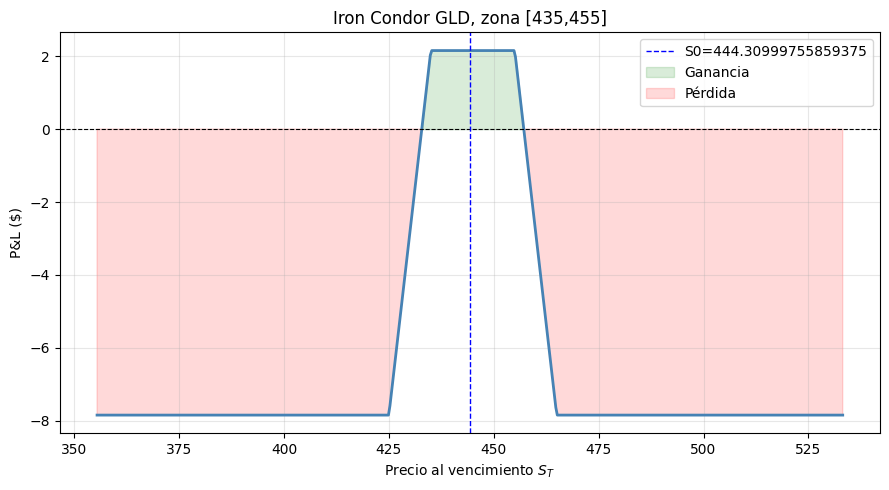

In [10]:
# 2. Iron Condor 
K_pl = strike_atm - 2*ancho
K_ps = strike_atm - ancho
K_cs = strike_atm + ancho
K_cl = strike_atm + 2*ancho

P_l = get_mid_price(puts, K_pl)
P_s = get_mid_price(puts, K_ps)
C_s = get_mid_price(calls, K_cs)
C_l = get_mid_price(calls, K_cl)

legs_condor = [
    {'tipo': 'put', 'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put', 'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]
pnl_condor = payoff_estrategia(S_range, legs_condor)
prima_cobrada_ic = (P_s - P_l) + (C_s - C_l)

print("\\n--- IRON CONDOR ---")
print(f"Prima cobrada     : ${prima_cobrada_ic:.2f}")
print(f"Pérdida máxima    : ${(K_ps - K_pl) - prima_cobrada_ic:.2f}")
graficar_estrategia(S_range, pnl_condor, f'Iron Condor GLD, zona [{K_ps},{K_cs}]', S0=S0)

\n--- COVERED CALL ---
Prima cobrada     : $1.36
Ganancia máxima   : $12.06


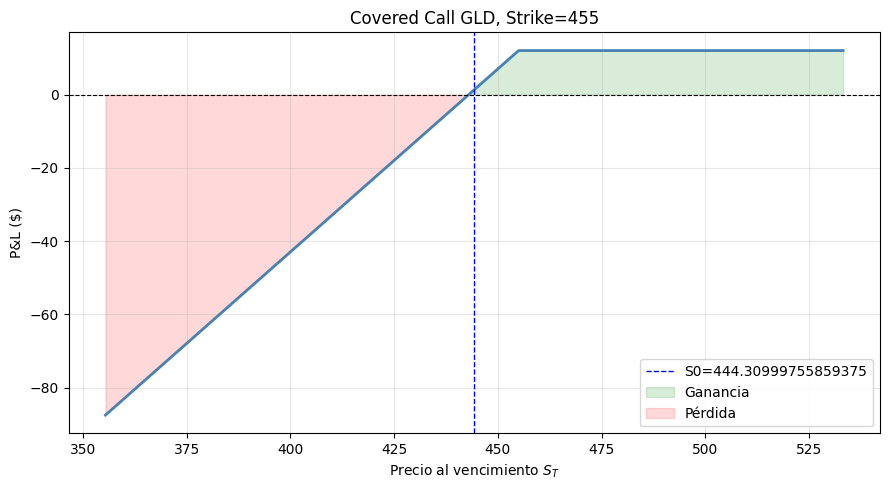

In [11]:
# 3. Covered Call
K_cc = strike_atm + ancho
C_cc = get_mid_price(calls, K_cc)

legs_cc = [
    {'tipo': 'call', 'K': 0, 'prima': S0, 'posicion': +1}, # Representa la acción comprada
    {'tipo': 'call', 'K': K_cc, 'prima': C_cc, 'posicion': -1},
]
# Ajuste manual para el payoff de la acción
pnl_cc = (S_range - S0) - np.maximum(S_range - K_cc, 0) + C_cc

print("\\n--- COVERED CALL ---")
print(f"Prima cobrada     : ${C_cc:.2f}")
print(f"Ganancia máxima   : ${K_cc - S0 + C_cc:.2f}")
graficar_estrategia(S_range, pnl_cc, f'Covered Call GLD, Strike={K_cc}', S0=S0)

\n--- PROTECTIVE PUT ---
Prima pagada      : $1.83
Pérdida máxima    : $11.14


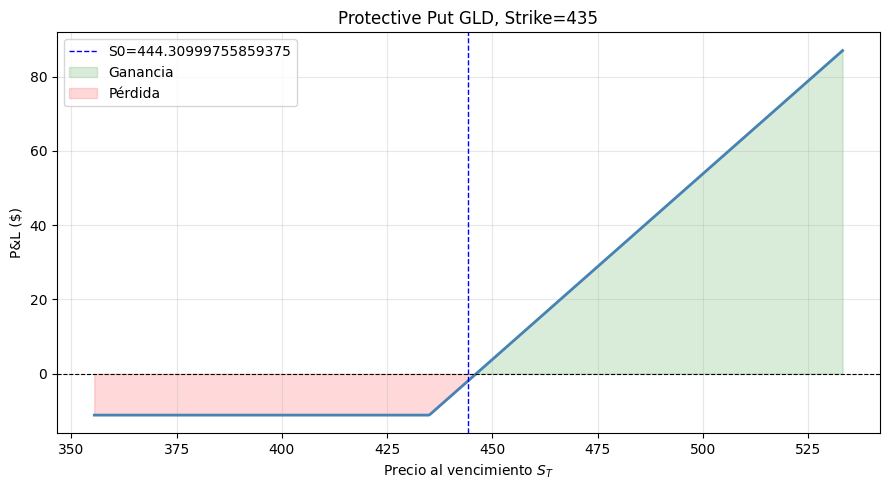

In [12]:
# 4. Protective Put
K_pp = strike_atm - ancho
P_pp = get_mid_price(puts, K_pp)

pnl_pp = (S_range - S0) + np.maximum(K_pp - S_range, 0) - P_pp

print("\\n--- PROTECTIVE PUT ---")
print(f"Prima pagada      : ${P_pp:.2f}")
print(f"Pérdida máxima    : ${S0 - K_pp + P_pp:.2f}")
graficar_estrategia(S_range, pnl_pp, f'Protective Put GLD, Strike={K_pp}', S0=S0)


## Preguntas
Responde dentro del notebook como celdas de texto (Markdown). Las respuestas deben estar fundamentadas en tus propias gráficas con los datos reales del día que corras el código.

1. **Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?** *Respuesta:*

Los strikes se configuraron alrededor del precio actual (At-The-Money), tanto el Butterfly Spread como el Iron Condor se encuentran posicionados en su zona de máxima ganancia desde el inicio. Un trader elegiría estas estrategias si tiene una visión de mercado neutral o lateral; es decir, si espera que el precio de GLD se mantenga estable y no experimente grandes movimientos hasta la fecha de vencimiento.

2. **Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.** *Respuesta:*

No, cobrar una prima neta desde el inicio no elimina el riesgo. El peor escenario ocurre si el precio experimenta un movimiento brusco, ya sea un alza fuerte o una caída severa, saliendo de la "zona segura" y superando los strikes de las opciones compradas (las alas de protección). En este caso, se sufre la pérdida máxima, la cual está limitada por la diferencia entre los strikes de los spreads menos la prima inicial que cobraste.

3. **Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.** *Respuesta:*

Sería preferible vender un Iron Condor. Cuando la Volatilidad Implícita (IV) es alta, las primas de las opciones están muy caras y vender volatilidad es más atractivo. Al vender un iron condor, la posición tiene vega negativa, lo que significa que ganarás dinero si la IV baja antes del vencimiento. Además, la estrategia tiene theta positiva, por lo que genera ganancias pasivas con el simple paso del tiempo. Por el contrario, comprar un straddle con una IV tan alta sería demasiado costoso y una caída en la volatilidad destruiría el valor de la posición.

4. **El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.** *Respuesta:*

- Generación de flujo de efectivo (Yield): Permite obtener ingresos periódicos al cobrar la prima en un mercado donde se espera que el precio del activo suba lentamente o se mantenga en rango.

- Reducción del costo base: La prima cobrada actúa como un pequeño amortiguador que reduce el impacto de las pérdidas si el precio del activo sufre una corrección moderada a la baja.

5. **Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".** *Respuesta:*

- Las analogías que funcionan: La prima pagada por el put es equivalente al costo de la póliza de seguro. Ambas coberturas tienen una fecha de caducidad (el vencimiento de la opción). La diferencia entre el precio actual y el strike funciona como el "deducible" (el nivel de pérdida que asumes antes de que la cobertura entre en vigor). Finalmente, si no hay siniestro (el precio no cae), la opción expira sin valor y "pierdes" el costo de la prima pagada.

- Dónde se rompe la analogía: La opción put tiene un valor en el mercado secundario (valor extrínseco) y puede ser revendida antes de su vencimiento para recuperar una parte de la prima. Un seguro de auto tradicional no puede ser revendido si decides que ya no lo necesitas a mitad de año.

6. **¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.** *Respuesta:*

- El Butterfly Spread requiere mucha mayor precisión en tu pronóstico, ya que su zona de máxima ganancia es un pico muy estrecho. Es ideal cuando tienes una expectativa muy concreta y exacta sobre dónde cerrará el precio al vencimiento.

- El Iron Condor ofrece una zona ancha de ganancia (una meseta), por lo que requiere menor precisión y permite un margen de error, siendo más apropiado para capturar la lateralidad general del mercado sin tener que acertar el precio exacto.

7. **Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?** *Respuesta:*

El valor de tu posición aumenta y registrarás una ganancia flotante. Como la estrategia tiene vega negativa, estructuralmente es una venta neta de volatilidad (la caída de IV beneficia a tus posiciones cortas más de lo que afecta a tus posiciones largas). Al caer la IV, todas las opciones se abaratan, lo que significa que recomprar las opciones centrales que vendiste te resultaría más barato hoy, dejándote con una ganancia por la contracción de las primas.